# Predicting Supreme Court Case Outcomes
### DTSC 2301 — Portfolio Project Two

**Problem:** Can characteristics of a Supreme Court case that are known *before* the Court
rules — issue area, lower court direction, jurisdiction, chief justice era, and similar
case attributes — predict whether the petitioner wins?

**Target:** `partyWinning` (1 = petitioner won, 0 = petitioner did not win) — binary classification.

**Scope:** Terms 2000–2025 (Rehnquist and Roberts courts), using the case-centered
Supreme Court Database (SCDB), 2026 Release 01.

This notebook covers data loading, cleaning, and exploratory data analysis (EDA).
Modeling is done in a separate notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

## 1. Load data

In [2]:
df_raw = pd.read_csv("SCDB_2026_01_caseCentered_Citation.csv", encoding="latin1")
print(f"Full dataset: {df_raw.shape[0]:,} cases, {df_raw.shape[1]} columns")
print(f"Term range: {df_raw.term.min()} - {df_raw.term.max()}")
df_raw.head()

Full dataset: 9,409 cases, 53 columns
Term range: 1946 - 2025


,caseId,docketId,caseIssuesId,voteId,dateDecision,decisionType,usCite,sctCite,ledCite,lexisCite,term,naturalCourt,chief,docket,caseName,dateArgument,dateRearg,petitioner,petitionerState,respondent,respondentState,jurisdiction,adminAction,adminActionState,threeJudgeFdc,caseOrigin,caseOriginState,caseSource,caseSourceState,lcDisagreement,certReason,lcDisposition,lcDispositionDirection,declarationUncon,caseDisposition,caseDispositionUnusual,partyWinning,precedentAlteration,voteUnclear,issue,issueArea,decisionDirection,decisionDirectionDissent,authorityDecision1,authorityDecision2,lawType,lawSupp,lawMinor,majOpinWriter,majOpinAssigner,splitVote,majVotes,minVotes
0,1946-001,1946-001-01,1946-001-01-01,1946-001-01-01-01,11/18/1946,1,329 U.S. 1,67 S. Ct. 6,91 L. Ed. 3,1946 U.S. LEXIS 1724,1946,1301,Vinson,24,HALLIBURTON OIL WELL CEMENTING CO. v. WALKER e...,1/9/1946,10/23/1946,198.0,NaN,172.0,NaN,6.0,NaN,NaN,0.0,51.0,6.0,29.0,NaN,0.0,11.0,2.0,1.0,1.0,3.0,0.0,1.0,1.0,0.0,80180.0,8.0,2.0,0.0,4.0,NaN,6.0,600.0,35 U.S.C. Â§ 33,78.0,78.0,1,8,1
1,1946-002,1946-002-01,1946-002-01-01,1946-002-01-01-01,11/18/1946,1,329 U.S. 14,67 S. Ct. 13,91 L. Ed. 12,1946 U.S. LEXIS 1725,1946,1301,Vinson,12,CLEVELAND v. UNITED STATES,10/10/1945,10/17/1946,100.0,NaN,27.0,NaN,1.0,NaN,NaN,0.0,123.0,52.0,30.0,NaN,0.0,4.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,10500.0,1.0,1.0,0.0,4.0,NaN,6.0,600.0,18 U.S.C. Â§ 398,81.0,87.0,1,6,3
2,1946-003,1946-003-01,1946-003-01-01,1946-003-01-01-01,11/18/1946,1,329 U.S. 29,67 S. Ct. 1,91 L. Ed. 22,1946 U.S. LEXIS 3037,1946,1301,Vinson,21,CHAMPLIN REFINING CO. v. UNITED STATES ET AL.,11/8/1945,10/18/1946,209.0,NaN,27.0,NaN,2.0,66.0,NaN,1.0,107.0,42.0,107.0,42.0,0.0,1.0,NaN,2.0,1.0,2.0,0.0,0.0,0.0,0.0,80250.0,8.0,2.0,0.0,1.0,NaN,2.0,207.0,NaN,84.0,78.0,1,5,4
3,1946-004,1946-004-01,1946-004-01-01,1946-004-01-01-01,11/25/1946,7,329 U.S. 40,67 S. Ct. 167,91 L. Ed. 29,1946 U.S. LEXIS 1696,1946,1301,Vinson,26,UNITED STATES v. ALCEA BAND OF TILLAMOOKS ET AL.,1/31/1946,10/25/1946,27.0,NaN,170.0,NaN,1.0,67.0,NaN,0.0,3.0,NaN,3.0,NaN,0.0,10.0,NaN,2.0,1.0,2.0,0.0,0.0,0.0,0.0,20150.0,2.0,2.0,0.0,4.0,NaN,6.0,600.0,49 Stat. 801,87.0,87.0,1,5,3
4,1946-005,1946-005-01,1946-005-01-01,1946-005-01-01-01,11/25/1946,1,329 U.S. 64,67 S. Ct. 154,91 L. Ed. 44,1946 U.S. LEXIS 2997,1946,1301,Vinson,50,"UNITED STATES v. HOWARD P. FOLEY CO., INC.",10/25/1946,NaN,27.0,NaN,176.0,NaN,1.0,NaN,NaN,0.0,3.0,NaN,3.0,NaN,0.0,2.0,NaN,2.0,1.0,3.0,0.0,1.0,0.0,0.0,80060.0,8.0,2.0,0.0,7.0,NaN,NaN,NaN,NaN,78.0,87.0,1,6,3


## 2. Scope the data: terms 2000–2025

The Court's composition, docket, and procedures have shifted a great deal since the
database begins in 1946. Restricting to 2000–2025 keeps enough cases to train and
evaluate models reliably while staying within two continuous, well-documented eras
(the end of the Rehnquist Court and the Roberts Court). The chief justice era is kept
as a feature rather than discarded, so the model can use it and we can later check
whether performance or important features differ across the two eras.

In [3]:
df = df_raw[(df_raw.term >= 2000) & (df_raw.term <= 2025)].copy()
print(f"2000-2025 subset: {df.shape[0]:,} cases")
df.chief.value_counts()

2000-2025 subset: 1,954 cases


chief
Roberts      1539
Rehnquist     415
Name: count, dtype: int64

## 3. Clean the target variable

`partyWinning` is coded:
- `1` = petitioner won
- `0` = petitioner did not win
- `2` = unclear outcome (rare catch-all code)
- missing = not codeable

We drop the unclear and missing rows. This is a small fraction of cases, and keeping
them would force us to guess at a label the database itself couldn't assign.

In [4]:
print("Before cleaning:")
print(df.partyWinning.value_counts(dropna=False))

n_before = len(df)
df = df[df.partyWinning.isin([0, 1])].copy()
df["partyWinning"] = df["partyWinning"].astype(int)
n_after = len(df)

print(f"\nDropped {n_before - n_after} cases with unclear/missing outcome.")
print(f"Remaining: {n_after:,} cases")
print(f"\nClass balance:\n{df.partyWinning.value_counts(normalize=True).round(3)}")

Before cleaning:
partyWinning
1.0    1336
0.0     613
2.0       5
Name: count, dtype: int64

Dropped 5 cases with unclear/missing outcome.
Remaining: 1,949 cases

Class balance:
partyWinning
1    0.685
0    0.315
Name: proportion, dtype: float64


**Baseline:** always predicting "petitioner wins" (the majority class) would be
correct roughly two-thirds of the time. Any model we build needs to clear that bar
to be worth using, and accuracy alone won't be a fair metric given this imbalance —
we'll lean on precision, recall, and F1 in the modeling notebook.

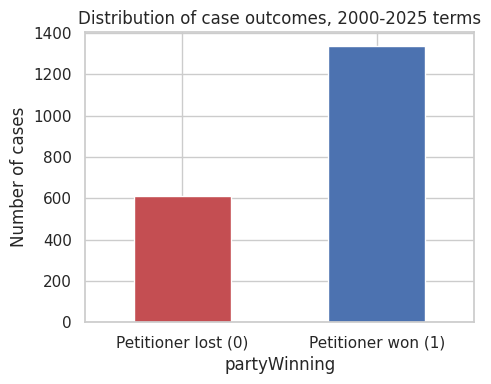

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df.partyWinning.value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#c44e52", "#4c72b0"]
)
ax.set_xticklabels(["Petitioner lost (0)", "Petitioner won (1)"], rotation=0)
ax.set_ylabel("Number of cases")
ax.set_title("Distribution of case outcomes, 2000-2025 terms")
plt.tight_layout()
plt.savefig("fig_target_distribution.png", dpi=150)
plt.show()

## 4. Select candidate pre-decision features

Following the brainstorming plan, features are restricted to information that is
known *before* the Court rules. Columns like `caseDisposition`, `decisionDirection`,
`majVotes`, `minVotes`, `splitVote`, and `majOpinWriter` are recorded only after the
decision and are excluded entirely — including any of these would leak the answer
into the model.

In [6]:
candidate_features = [
    "issueArea",       # broad legal subject of the case
    "petitioner",      # type of petitioning party
    "respondent",      # type of respondent party
    "jurisdiction",    # how the Court took the case
    "caseOrigin",      # court where the case originated
    "caseSource",      # court whose decision is being reviewed
    "lcDisagreement",  # whether there was disagreement among lower courts
    "certReason",      # stated reason cert was granted
    "lcDispositionDirection",  # ideological direction of the lower court ruling
    "threeJudgeFdc",   # whether a three-judge federal district court was involved
    "term",            # year decided
    "chief",           # chief justice era (Rehnquist / Roberts)
]

leakage_columns = [
    "caseDisposition", "caseDispositionUnusual", "decisionDirection",
    "decisionDirectionDissent", "majVotes", "minVotes", "splitVote",
    "majOpinWriter", "majOpinAssigner", "precedentAlteration", "voteUnclear",
    "authorityDecision1", "authorityDecision2", "lawType", "lawSupp", "lawMinor",
]

print("Candidate features (pre-decision, allowed):")
for c in candidate_features:
    print(" -", c)

print("\nExcluded as leakage (post-decision, NOT used as features):")
for c in leakage_columns:
    print(" -", c)

Candidate features (pre-decision, allowed):
 - issueArea
 - petitioner
 - respondent
 - jurisdiction
 - caseOrigin
 - caseSource
 - lcDisagreement
 - certReason
 - lcDispositionDirection
 - threeJudgeFdc
 - term
 - chief

Excluded as leakage (post-decision, NOT used as features):
 - caseDisposition
 - caseDispositionUnusual
 - decisionDirection
 - decisionDirectionDissent
 - majVotes
 - minVotes
 - splitVote
 - majOpinWriter
 - majOpinAssigner
 - precedentAlteration
 - voteUnclear
 - authorityDecision1
 - authorityDecision2
 - lawType
 - lawSupp
 - lawMinor


## 5. Missing values in the selected features

In [7]:
missing = (
    df[candidate_features].isna().mean().mul(100).round(1)
    .sort_values(ascending=False)
    .rename("pct_missing")
)
missing.to_frame()

,pct_missing
caseOrigin,1.8
lcDispositionDirection,1.7
caseSource,1.2
lcDisagreement,1.2
threeJudgeFdc,1.2
certReason,0.9
issueArea,0.5
respondent,0.3
petitioner,0.2
jurisdiction,0.1


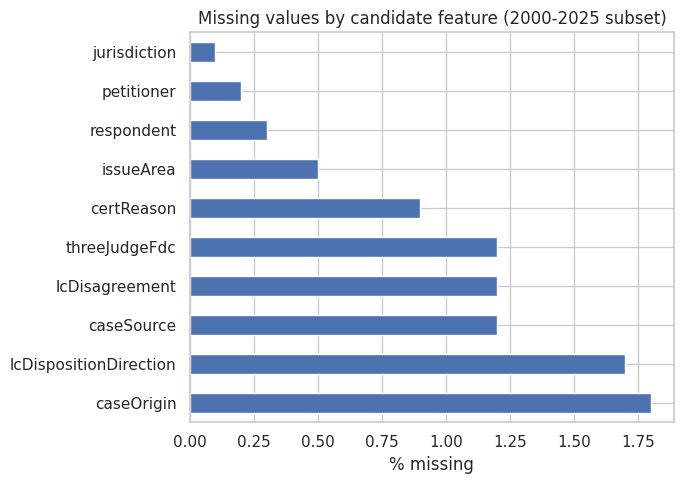

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
missing[missing > 0].plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("% missing")
ax.set_title("Missing values by candidate feature (2000-2025 subset)")
plt.tight_layout()
plt.savefig("fig_missingness.png", dpi=150)
plt.show()

Most candidate features are missing in well under 5% of cases in this subset.
`lcDispositionDirection` and `lcDisposition`-adjacent fields tend to run a bit higher
because some cases don't have a single, direction-codable lower court ruling (for
example, original-jurisdiction cases). Rows with missing values in a given feature
will be handled in preprocessing (documented in the modeling notebook) — options are
dropping those rows or coding missingness itself as a category, since for a few of
these fields "not applicable" is informative rather than random.

## 6. Distribution of key features

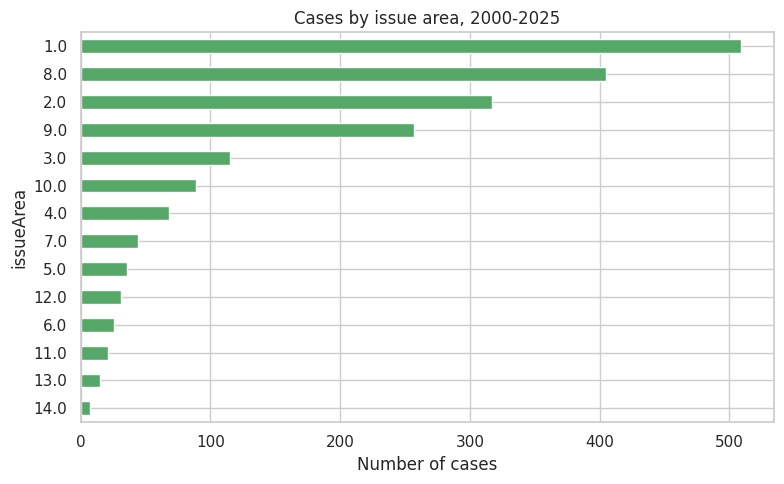

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
df.issueArea.value_counts().sort_values().plot(kind="barh", ax=ax, color="#55a868")
ax.set_xlabel("Number of cases")
ax.set_title("Cases by issue area, 2000-2025")
plt.tight_layout()
plt.savefig("fig_issue_area.png", dpi=150)
plt.show()

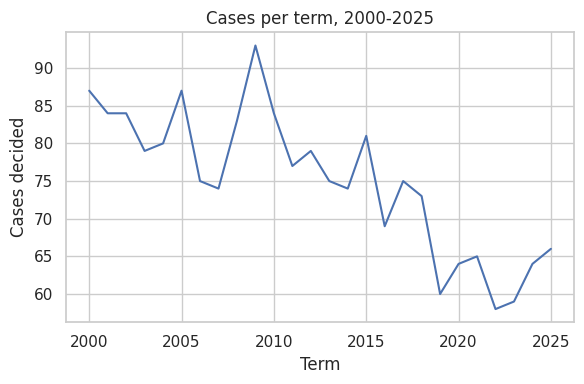

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby("term").size().plot(ax=ax, color="#4c72b0")
ax.set_ylabel("Cases decided")
ax.set_xlabel("Term")
ax.set_title("Cases per term, 2000-2025")
plt.tight_layout()
plt.savefig("fig_cases_per_term.png", dpi=150)
plt.show()

## 7. Does the outcome vary by feature? (informs feature selection)

A quick cross-tab of petitioner win rate by issue area and by chief justice era.
Categories with a win rate noticeably different from the ~65% overall rate are
good candidates for informative features; categories that track the overall rate
closely add less signal.

In [11]:
win_by_issue = (
    df.groupby("issueArea")["partyWinning"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "petitioner_win_rate", "count": "n_cases"})
    .sort_values("petitioner_win_rate", ascending=False)
)
win_by_issue.round(3)

,petitioner_win_rate,n_cases
issueArea,,
5.0,0.778,36
4.0,0.750,68
13.0,0.733,15
6.0,0.731,26
3.0,0.730,115
2.0,0.722,317
1.0,0.719,509
14.0,0.714,7
7.0,0.682,44


In [12]:
win_by_chief = (
    df.groupby("chief")["partyWinning"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "petitioner_win_rate", "count": "n_cases"})
)
win_by_chief.round(3)

,petitioner_win_rate,n_cases
chief,,
Rehnquist,0.684,414
Roberts,0.686,1535


## 8. Save the cleaned dataset

This cleaned, scoped file (target cleaned, restricted to 2000-2025, leakage columns
already excluded) is the starting point for the modeling notebook, which will handle
encoding, the train/test split, the baseline, and model training.

In [13]:
cleaned = df[["caseId", "partyWinning"] + candidate_features].copy()
cleaned.to_csv("scdb_cleaned_2000_2025.csv", index=False)
print(f"Saved {cleaned.shape[0]:,} rows, {cleaned.shape[1]} columns to scdb_cleaned_2000_2025.csv")
cleaned.head()

Saved 1,949 rows, 14 columns to scdb_cleaned_2000_2025.csv


,caseId,partyWinning,issueArea,petitioner,respondent,jurisdiction,caseOrigin,caseSource,lcDisagreement,certReason,lcDispositionDirection,threeJudgeFdc,term,chief
7455,2000-001,1,2.0,28.0,28.0,9.0,NaN,NaN,0.0,1.0,NaN,0.0,2000,Rehnquist
7456,2000-002,0,1.0,28.0,137.0,1.0,94.0,22.0,0.0,12.0,2.0,0.0,2000,Rehnquist
7457,2000-003,1,1.0,177.0,27.0,1.0,75.0,25.0,0.0,2.0,2.0,0.0,2000,Rehnquist
7458,2000-004,1,9.0,251.0,251.0,2.0,41.0,41.0,0.0,1.0,2.0,1.0,2000,Rehnquist
7459,2000-005,0,1.0,3.0,214.0,1.0,69.0,27.0,0.0,12.0,2.0,0.0,2000,Rehnquist
